Using: ..\data\PlantVillage
Classes: 15 | Images: 20639


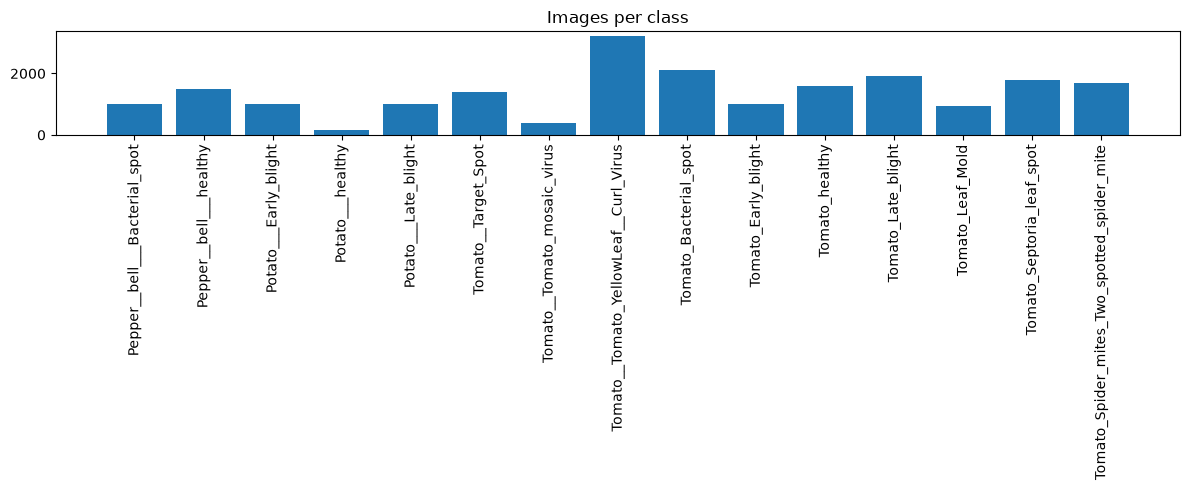

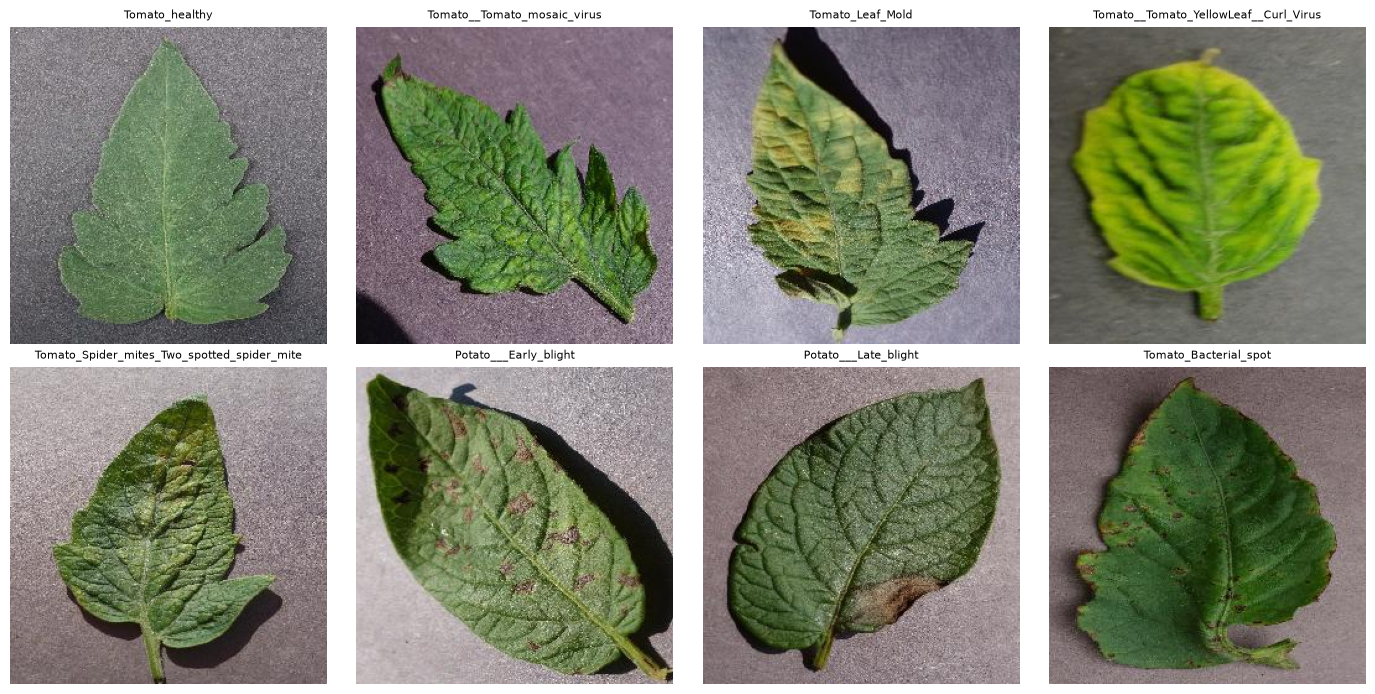

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Find the folder that holds the class folders
root = Path("../data")
data_dir = [p for p in root.rglob("*")
            if p.is_dir() and sum(c.is_dir() for c in p.iterdir()) >= 10][0]
print("Using:", data_dir)

# Count images per class
classes = sorted(c for c in data_dir.iterdir() if c.is_dir())
counts = {c.name: len(list(c.glob("*"))) for c in classes}
print("Classes:", len(classes), "| Images:", sum(counts.values()))

# Plot the class distribution
plt.figure(figsize=(12, 5))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=90)
plt.title("Images per class")
plt.tight_layout()
plt.show()

# Show 8 random samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, c in zip(axes.flatten(), random.sample(classes, 8)):
    img_path = random.choice(list(c.glob("*")))
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(c.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [2]:
from PIL import Image
sample = next(next(data_dir.iterdir()).glob("*"))
print("Image size:", Image.open(sample).size)

Image size: (256, 256)


## Findings
- 15 classes, 20,639 images
- Classes are imbalanced (Potato healthy has only 152 images)
- Images are 256x256 